In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick
import numpy as np

ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [106]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4 = jax.random.split(rng, 5)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.6, shape=(3,))
    model_mask = jnp.array([True, True, True])
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    x_o = x_o + jax.random.normal(rng4, shape=x_o.shape) * 0.01
    return model_mask, theta, x_o, bvals, bvecs
    

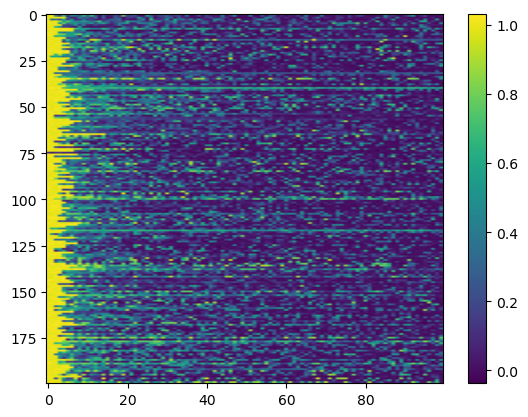

In [107]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto')
plt.colorbar()

In [1]:
from dmri.nn.tokenizer import StructuredTokenizer
from dmri.nn.autoregressive import BinaryAutoregressiveDecoder
from dmri.nn.simformer import Simformer, MLP, EDM
from dmri.nn.embedding_net import BvalBvecSignalEmbeddingNet
from flax import nnx


dims_per_component = list(ball_stick.split_idx())
node_ids = [0,1,2,3]
tokenizer = StructuredTokenizer(dims_per_component, rngs=nnx.Rngs(0))
embed_net = BvalBvecSignalEmbeddingNet(nnx.Rngs(1), 2000)
simformer = Simformer(tokenizer, rngs=nnx.Rngs(3), num_layers=6)


class Model(nnx.Module, experimental_pytree=True):
    def __init__(self, embed_net, simformer):
        self.embed_net = embed_net
        self.simformer = simformer
        
    def __call__(self, t, theta, node_ids, bvals, bvecs, x_o):
        y = self.embed_net(bvals, bvecs, x_o)
        x = self.simformer(t, theta, node_ids=node_ids, y=y)
        return x
    

model = EDM(Model(embed_net, simformer), 1.)
params = nnx.state(model, nnx.Param)

NameError: name 'ball_stick' is not defined

In [109]:
nnx.update(model, params)

In [110]:
model(jnp.ones((200,1)), theta, node_ids, bvals, bvecs, x_o)

Array([[-0.033, -0.161, -0.042, ..., -0.102, -0.441, -0.606],
       [ 0.608, -0.568, -0.165, ..., -0.005, -0.606,  0.334],
       [ 0.956, -0.667,  0.617, ...,  0.472, -0.467, -0.124],
       ...,
       [-0.204, -1.072, -0.965, ...,  0.402, -0.075, -0.995],
       [ 0.72 , -0.903, -0.153, ...,  0.113, -1.057, -0.157],
       [-0.646,  0.149, -0.624, ..., -0.722, -0.636, -0.331]],      dtype=float32)

In [111]:
import optax 


optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adamw(1e-4))


@jax.jit
def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data

    loss = model.loss(params, rng=rng, data=thetas, node_ids=node_ids, bvals=bvals, bvecs=bvecs, x_o=xs)

    return loss

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss


In [112]:
batch_simulator = jax.jit(jax.vmap(simulator))
opt_state = optimizer.init(params)

In [118]:
key = jax.random.PRNGKey(2)
for i in range(50):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (128,), 0, 2**16)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500) 

382.22406
376.68784
435.16486
608.0079
362.67615
391.46445
335.0515
260.87805
232.36676
291.37894
230.44579
316.60068
343.1701
243.32019
268.4958
233.18678
318.80133


KeyboardInterrupt: 

In [119]:
nnx.update(model, params)

In [120]:
from probjax.utils.odeint import odeint

model.max_noise = 40.

def sample(rng, bvals, bvecs, x_o):
    eps = jax.random.normal(rng, ball_stick.theta_dim) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(16)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, node_ids=node_ids, bvals=bvals, bvecs=bvecs, x_o=x_o)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


# from probjax.utils.sdeint import sdeint

# def sample(rng, context):
#     model = simformer
#     rng_init, rng_sample = jax.random.split(rng)
#     eps = jax.random.normal(rng_init, (ball_stick.theta_dim,))  * model.marginal_std(model.max_noise)
#     ts = model.solve_schedule(200)

#     def drift(t, x):
#         t = jnp.atleast_1d(t)
#         f = model.drift(t,x)
#         g = model.diffusion(t,x)
#         score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)

#         drift_backward = f - g**2 * score
#         return drift_backward
    
#     def diffusion(t, x):
#         t = jnp.atleast_1d(t)
#         g = model.diffusion(t,x)
#         return g
    
#     return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    


In [121]:
thetas_post = jax.vmap(sample, in_axes=(0, None, None, None))(jax.random.split(jax.random.key(0), 1000), bvals[0], bevecs[0], x_os[0])

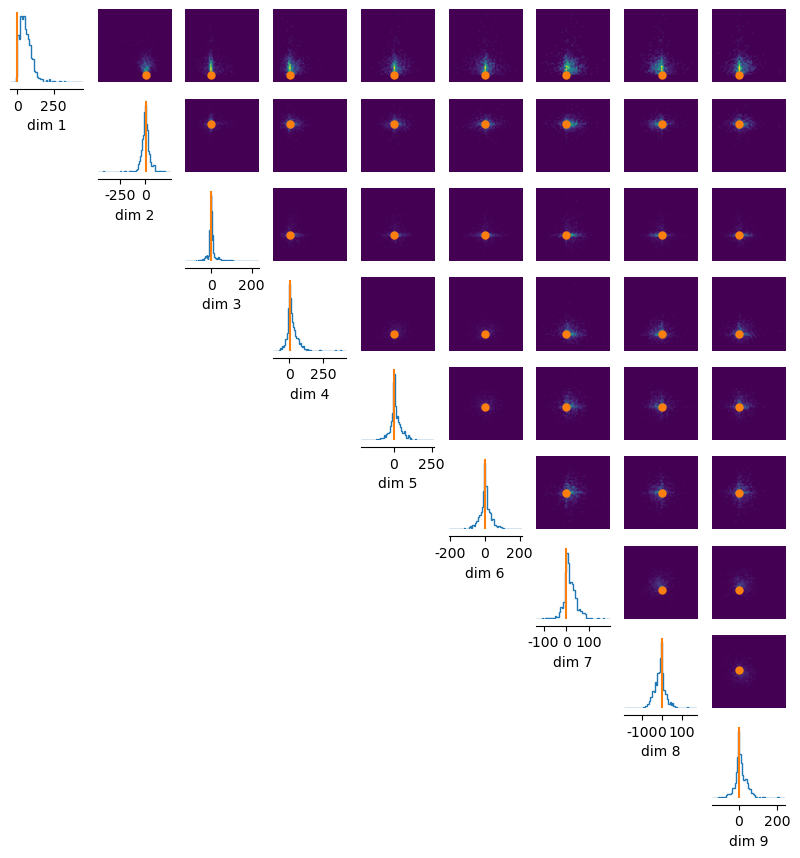

In [122]:
import sbi.analysis.plot 
from sbi.analysis.plot import pairplot
import numpy as np


_ = pairplot(thetas_post, points=thetas[:1])

In [98]:
def posterior_pred(theta):
    return Ball2Stick.from_theta(theta).signal(bvals[0], bevecs[0])

posterior_preds = jax.vmap(posterior_pred)(thetas_post[::10])

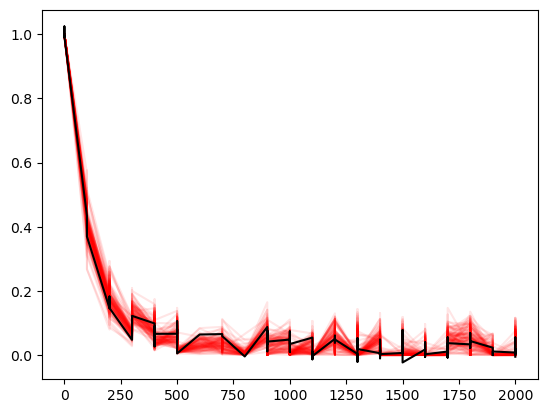

In [101]:
_ = plt.plot(bvals[0], posterior_preds.T, label="posterior pred", color="red", alpha=0.1)
_ = plt.plot(bvals[0], x_os[0], label="data", color="black")